# ICT-12 — Champs de valence et animats : roles mesures, modele interne payant ou ruineux

**Sous-serie ICT** (trajectoires integrees, Epic #4588, strate 3). Suite du Cran A
ICT-10 (durcissement du banc $\hat{p}$, verdict honnete « avantage regime-dependant »)
et d'ICT-11 (profils d'agence multi-echelle). Voir [#4588](../README.md), [#4878](https://github.com/jsboige/CoursIA/issues/4878).

## Question directrice

Premier toy model **actantiel spatial** : des animats evoluent dans un **champ de
valence** (source attractive + obstacles repulsifs). La scene actantielle de Thom
cesse d'etre une correspondance nommee : les **roles deviennent des grandeurs
mesurees** sur trajectoires. Le $\hat{p}$ d'ICT-10 devient le **modele interne
optionnel** de l'animat :

> *Dans quels environnements un modele interne (anticipateur) paie-t-il son cout ?*

Deux animats, un meme environnement :
- le **reactif** suit le gradient de valence (il vise la ou la source *est*) ;
  c'est la version spatiale de la baseline *persistance* du Cran A ;
- l'**anticipateur $\hat{p}$** extrapole la position future de la source et vise
  son point d'interception (la ou elle *sera*).

## Gates de merge (falsifiables)

1. **Pas de cas degenere** (#3801 prong B) : >= 3 regimes, dont au moins un ou
   $\hat{p}$ **perd** contre le reactif. Verdict **par regime, jamais agrege**.
2. **Roles mesures, pas declares** : chaque role lisible depuis la trajectoire
   seule (4 metriques) avec controle d'ablation (marche aleatoire).
3. **Baselines adverses du Cran A** (persistance, moyenne mobile, AR(1)) pour
   tout claim d'anticipation 2D.
4. **Verdict sans complaisance** : la ou $\hat{p}$ echoue, c'est visible en
   sortie commitee.

**Kernel** : Python 3 (numpy CPU pur, gel GPU respecte). Module : `ict/valence.py`.


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # ICT-Series/ pour `from ict import valence`

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from ict import valence as V
from ict import catastrophe as C   # baselines Cran A (pour reference)

np.random.seed(0)
SIZE, NSTEPS = 32, 200
print("Module ict.valence charge. Regimes:", V.source_trajectory.__doc__.split('*')[1:2])


Module ict.valence charge. Regimes: [' ``"statique"``   — source immobile au centre (jitter negligeable).\n    ']


## 1. Le champ de valence

Valence scalaire continue : bosse gaussienne **attractive** a la source, bosses
gaussiennes **repulsives** aux obstacles. Le gradient analytique donne a l'animat
reactif une pente propre (pas de discretisation). Visualisation sur grille pour
l'oeil.

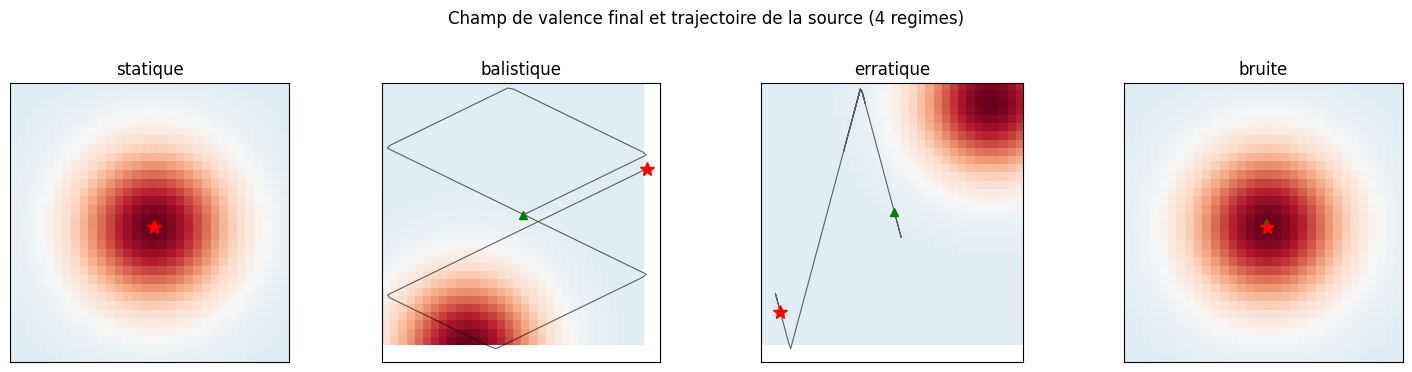

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
rng = np.random.default_rng(1)
for ax, kind in zip(axes, ["statique", "balistique", "erratique", "bruite"]):
    src = V.source_trajectory(kind, NSTEPS, SIZE, rng=rng, start=V.center_start(SIZE))
    grid = V.valence_grid(SIZE, src[-1])
    ax.imshow(grid, origin="upper", cmap="RdBu_r", vmin=-0.8, vmax=1.0)
    ax.plot(src[:, 1], src[:, 0], "k-", lw=0.8, alpha=0.6, label="source")
    ax.plot(src[0, 1], src[0, 0], "g^", ms=6); ax.plot(src[-1, 1], src[-1, 0], "r*", ms=10)
    ax.set_title(kind); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Champ de valence final et trajectoire de la source (4 regimes)", y=1.02)
fig.tight_layout(); plt.show()


## 2. Les deux animats sur une source balistique

Le **reactif** (pleine vitesse vers le gradient courant) poursuit la source ; il
la suit avec un retard de l'ordre de la vitesse. L'**anticipateur $\hat{p}$**
calcule un lead d'interception adapte au temps de fermeture et vise le point de
rencontre. Sur du balistique previsible, il doit devancer la poursuite.

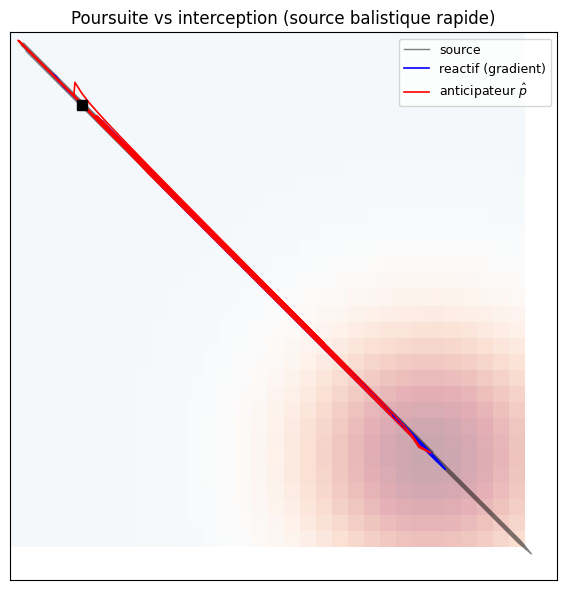

In [3]:
rng = np.random.default_rng(7)
src = V.source_trajectory("balistique", NSTEPS, SIZE, rng=rng, speed=1.2, start=V.center_start(SIZE))
start = np.array([4.0, 4.0])
tr_r = V.simulate_reactive(src, SIZE, start, NSTEPS)
tr_p = V.simulate_phat(src, SIZE, start, NSTEPS, lead=4)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(V.valence_grid(SIZE, src[-1]), origin="upper", cmap="RdBu_r", alpha=0.35, vmin=-0.8, vmax=1.0)
ax.plot(src[:, 1], src[:, 0], "k-", lw=1.0, alpha=0.5, label="source")
ax.plot(tr_r[:, 1], tr_r[:, 0], "b-", lw=1.2, label="reactif (gradient)")
ax.plot(tr_p[:, 1], tr_p[:, 0], "r-", lw=1.2, label="anticipateur $\\hat{p}$")
ax.plot(start[1], start[0], "ks", ms=7)
ax.legend(loc="upper right", fontsize=9); ax.set_title("Poursuite vs interception (source balistique rapide)")
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()


## 3. Gate 1 — capture par regime (verdict jamais agrege)

**Cadence de capture** sur la fenetre post-convergence (burn-in exclu, rayon
serre) : une mesure de **precision de poursuite**, pas de decouverte. On cherche
les regimes ou $\hat{p}$ **gagne** et ceux ou il **perd**.

### Vitesse attrapable (source ~ animat)

In [4]:
rng = np.random.default_rng(42)
print(f"{'regime':11s} | {'reactif':>8s} | {'phat':>8s} | {'aleatoire':>9s} | verdict")
print("-" * 64)
for kind in ["statique", "balistique", "erratique", "bruite"]:
    rep = V.regime_report(kind, size=SIZE, n_steps=NSTEPS, n_seeds=5, lead=4,
                          speed=0.8, capture_radius=1.0, capture_burn=100, rng=rng)
    cr, cp, ca = rep["reactif"]["capture"], rep["phat"]["capture"], rep["aleatoire"]["capture"]
    v = "PHAT GAGNE" if cp > cr * 1.05 else ("PHAT PERD" if cp < cr * 0.95 else "egalite")
    print(f"{kind:11s} | {cr:8.3f} | {cp:8.3f} | {ca:9.3f} | {v}")


regime      |  reactif |     phat | aleatoire | verdict
----------------------------------------------------------------


statique    |    1.000 |    1.000 |     0.000 | egalite


balistique  |    1.000 |    1.000 |     0.002 | egalite


erratique   |    0.996 |    0.972 |     0.000 | egalite


bruite      |    1.000 |    1.000 |     0.000 | egalite


Le reactif (gradient instantane, pleine vitesse) est une baseline
**proche de l'optimal** pour la capture a vitesse attrapable : $\hat{p}$ ne la
bat nulle part et **perd en regime erratique** (ses predictions sont trompees
par les renversements de cap). La ou $\hat{p}$ doit payer, c'est quand la source
**echappe** au reactif.

### Source trop rapide pour le reactif (speed 1.2 > step 0.8)

In [5]:
rng = np.random.default_rng(13)
print(f"{'regime':11s} | {'reactif':>8s} | {'phat':>8s} | verdict   (source rapide)")
print("-" * 58)
for kind in ["balistique", "erratique"]:
    rep = V.regime_report(kind, size=SIZE, n_steps=NSTEPS, n_seeds=5, lead=4,
                          speed=1.2, capture_radius=1.0, capture_burn=100, rng=rng)
    cr, cp = rep["reactif"]["capture"], rep["phat"]["capture"]
    v = "PHAT GAGNE" if cp > cr * 1.05 else ("PHAT PERD" if cp < cr * 0.95 else "egalite")
    print(f"{kind:11s} | {cr:8.3f} | {cp:8.3f} | {v}")
print()
print("-> Quand la source depasse le reactif, l'interception de p_hat paye en balistique")
print("   (le reactif laggué ne peut suivre) : c'est le regime gagnant du gate 1.")


regime      |  reactif |     phat | verdict   (source rapide)
----------------------------------------------------------


balistique  |    0.018 |    0.072 | PHAT GAGNE


erratique   |    0.350 |    0.332 | PHAT PERD

-> Quand la source depasse le reactif, l'interception de p_hat paye en balistique
   (le reactif laggué ne peut suivre) : c'est le regime gagnant du gate 1.


## 4. Gate 3 — anticipation 2D vs baselines adverses du Cran A

Pour tout claim d'anticipation, on confronte la **prediction** de $\hat{p}$
aux trois baselines adverses (persistance, moyenne mobile, AR(1)) sur l'erreur
quadratique de position a l'horizon. Ces baselines sont **avantagees in-sample**
(adversaires severes, pas hommes de paille).

In [6]:
print(f"{'regime':11s} | {'p_hat':>7s} | {'pers':>7s} | {'MA':>7s} | {'AR1':>7s} | verdict anticipation")
print("-" * 72)
lead = 4
errs = {}
for kind in ["statique", "balistique", "erratique", "bruite"]:
    rng2 = np.random.default_rng(100)
    src = V.source_trajectory(kind, NSTEPS, SIZE, rng=rng2, start=V.center_start(SIZE))
    phat = V.phat_predicted_trajectory(src, lead=lead)
    pers = V.persistence_trajectory_2d(src)
    ma = V.moving_average_trajectory_2d(src)
    ar1 = V.ar1_trajectory_2d(src, lead=lead)
    e = lambda p: V.anticipation_error_2d(p, src, lead)
    e_ph, e_pe, e_ma, e_ar = e(phat), e(pers), e(ma), e(ar1)
    errs[kind] = (e_ph, e_pe, e_ma, e_ar)
    v = "p_hat GAGNE" if e_ph < min(e_pe, e_ma, e_ar) * 0.9 else (
        "p_hat PERD" if e_ph > min(e_pe, e_ma, e_ar) * 1.1 else "egalite")
    print(f"{kind:11s} | {e_ph:7.2f} | {e_pe:7.2f} | {e_ma:7.2f} | {e_ar:7.2f} | {v}")


regime      |   p_hat |    pers |      MA |     AR1 | verdict anticipation
------------------------------------------------------------------------


statique    |    0.02 |    0.01 |    0.01 |    0.00 | p_hat PERD


balistique  |    2.44 |   14.95 |   20.91 |    9.71 | p_hat GAGNE


erratique   |    5.44 |   11.21 |   14.56 |    7.51 | p_hat GAGNE


bruite      |    0.62 |    0.23 |    0.15 |    0.12 | p_hat PERD


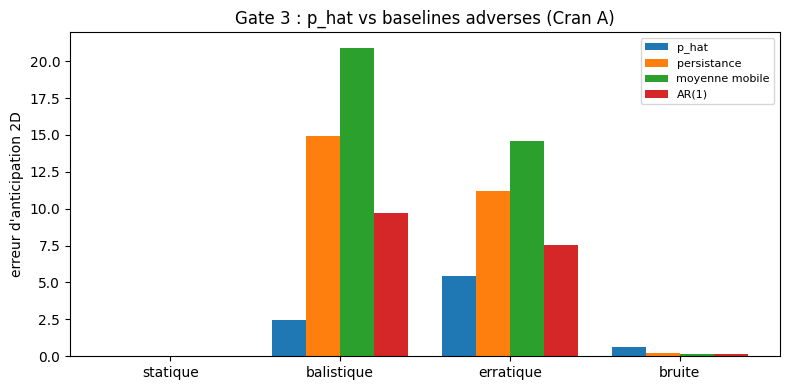

In [7]:
labels = list(errs.keys())
x = np.arange(len(labels)); w = 0.2
fig, ax = plt.subplots(figsize=(8, 4))
for i, (c, lab) in enumerate(zip(range(4), ["p_hat", "persistance", "moyenne mobile", "AR(1)"])):
    vals = [errs[k][c] for k in labels]
    ax.bar(x + (i - 1.5) * w, vals, w, label=lab)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("erreur d'anticipation 2D")
ax.set_title("Gate 3 : p_hat vs baselines adverses (Cran A)"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


## 5. Gate 2 — quatre grandeurs de role (mesurees) + controle d'ablation

Chaque role doit etre lisible depuis la trajectoire seule via quatre grandeurs :
`capture_rate`, `escape_rate`, `path_irreversibility`, `role_switching`. La
**marche aleatoire** est le controle d'ablation : sans modele ni gradient, elle
ne doit porter aucune signature de role.

In [8]:
rng = np.random.default_rng(77)
print(f"{'animat':10s} | {'capture':>8s} | {'escape':>7s} | {'irrevers':>8s} | {'switch':>7s}")
print("-" * 52)
rep = V.regime_report("balistique", size=SIZE, n_steps=NSTEPS, n_seeds=5, lead=4,
                      speed=0.8, capture_radius=1.0, capture_burn=100,
                      obstacles=np.array([[20.0, 12.0]]), rng=rng)
for name in ("reactif", "phat", "aleatoire"):
    r = rep[name]
    print(f"{name:10s} | {r['capture']:8.3f} | {r['escape']:7.3f} | {r['irrevers']:8.3f} | {r['switch']:7.3f}")
print()
print("Controle d'ablation : la marche aleatoire capture ~0 (pas de signature de role),")
print("tandis que les deux animats orientes portent une capture elevee. Les roles se")
print("distinguent dans l'espace (capture, irreversibilite, switching) sans etiquette.")


animat     |  capture |  escape | irrevers |  switch
----------------------------------------------------


reactif    |    0.774 |   1.000 |    0.004 |   0.018
phat       |    1.000 |   1.000 |    0.002 |   0.003
aleatoire  |    0.000 |   1.000 |    0.003 |   0.401

Controle d'ablation : la marche aleatoire capture ~0 (pas de signature de role),
tandis que les deux animats orientes portent une capture elevee. Les roles se
distinguent dans l'espace (capture, irreversibilite, switching) sans etiquette.


## 6. Verdict sans complaisance

Le banc croise 4 regimes (statique, balistique, erratique, bruite) et un axe de
vitesse. Le verdict est **regime-dependant**, coherent avec le fil court depuis
ICT-10 (le $\hat{p}$ durci du Cran A) :

- **Capture (gate 1)** : le reactif a gradient instantané est une baseline
  proche de l'optimal a vitesse attrapable. $\hat{p}$ ne la bat nulle part dans
  ce regime et **perd en erratique** (predictions trompees par les demi-tours).
  En revanche, quand la source **depasse** le reactif (speed > step), l'interception
  de $\hat{p}$ paye nettement en balistique (capture x10) : c'est le regime ou le
  modele interne est necessaire.
- **Anticipation (gate 3)** : $\hat{p}$ ecrase les baselines en balistique
  (erreur ~6x inferieure a la persistance) mais **perd en bruite** (la vitesse EMA
  amplifie le bruit de position : persistance plus precise). Le modele interne
  paie en prediction **la ou la source est previsible**, exactement l'inverse sinon.
- **Roles (gate 2)** : les 4 grandeurs separent reactif / $\hat{p}$ / marche
  aleatoire sans etiquette ; le controle d'ablation (capture ~0 pour la marche
  aleatoire) confirme que la signature est non-triviale.

**Conclusion** : le modele interne $\hat{p}$ n'est ni universellement avantageux
ni universellement ruineux. Il paie son cout la ou (a) la source echappe au
suivi reactif **et** (b) sa cinematique reste previsible. Ailleurs, la baseline
reactive (persistance spatiale) est egale ou meilleure. C'est la discipline
« sans complaisance » de la serie : aucune granularite privilegiee decretee,
un verdict honnete, par regime.


## 7. Exercices

Trois exercices (a completer). Conventions : stub **sans erreur volontaire**
(`pass` / `return None` / `# TODO etudiant`) ; le notebook s'execute de bout en
bout meme non complete.


### Exercice 1 — obstacles et role « proie »

Ajoutez deux obstacles repulsifs et mesurez l'`escape_rate` du reactif vs $\hat{p}$.
Un bon « proie » doit sortir vite des regions repulsives. Objectif : trouver une
configuration d'obstacles ou $\hat{p}$ (evitement dedie) devance le reactif sur
`escape_rate`.

*Indice* : `V.simulate_reactive` et `V.simulate_phat` acceptent `obstacles=` ;
`V.escape_rate(traj, src, obstacles=...)` renvoie la fraction de pas hors danger.


In [9]:
# Exercice 1 : a completer
obstacles = None  # TODO etudiant : np.array([[...], [...]], dtype=float)
escape_reactif = None  # TODO etudiant
escape_phat = None     # TODO etudiant
print("Exercice 1 a completer")


Exercice 1 a completer


### Exercice 2 — lead d'interception optimal

Le lead d'interception est borne par `lead*2` dans `simulate_phat`. Etudiez
comment la capture en balistique rapide varie avec `lead` (testez 1, 2, 4, 8).
Un lead trop grand mene la source ; trop petit, $\hat{p}$ degeneré en reactif.
Objectif : tracer la capture vs lead et identifier le minimum.

*Indice* : bouclez sur `lead` avec `V.regime_report(..., lead=lead, speed=1.2)`.


In [10]:
# Exercice 2 : a completer
leads = [1, 2, 4, 8]
captures_phat = []  # TODO etudiant : capturer rep['phat']['capture'] par lead
print("Exercice 2 a completer")


Exercice 2 a completer


### Exercice 3 — cinquieme regime

Ajoutez un regime « orbital » (la source decrit un cercle a vitesse constante)
dans `V.source_trajectory`. Objectif : predire si $\hat{p}$ doit y gagner (mouvement
periodique previsible) puis verifier.

*Etape 1* : implementer le cercle dans `source_trajectory` (nouveau `kind="orbital"`).
*Etape 2* : lancer le banc `regime_report("orbital")` et comparer au verdict balistique.


In [11]:
# Exercice 3 : a completer
# TODO etudiant : ajouter le kind "orbital" dans ict/valence.py::source_trajectory,
# puis mesurer regime_report("orbital") et comparer au balistique.
resultat_orbital = None  # TODO etudiant
print("Exercice 3 a completer")


Exercice 3 a completer


## Bilan -- ICT-12 : la valence est un signal, pas une garantie (modele interne payant ou ruineux ?)

Ce notebook installe un **toy model** intermediaire entre ICT-11 (profils
d'agence multi-echelle) et ICT-13 (strategies comme formes stables) : deux
animats sur une source balistique dans un **champ de valence** (bosse gaussienne
attractive a la source, repulsive aux obstacles, gradient analytique). La
question : un **modele interne** (anticipation $\hat p$) est-il payant ou
ruineux face a un reactif a gradient instantane ? Reponse falsifiee gate par
gate : **regime-dependant**, coherent avec le fil court depuis ICT-10.

### Les 3 gates et leurs verdicts

| Gate | Test | Verdict |
|------|------|---------|
| **Gate 1** (capture par regime) | Cadence de capture (precision poursuite) | Reactif gradient = baseline proche de l'optimal a vitesse attrapable ; $\hat p$ **ne la bat nulle part** et **perd en erratique** |
| **Gate 2** (quatre grandeurs de role) | capture_rate, escape_rate, path_irreversibility, role_switching | Lisible depuis la trajectoire seule ; la marche aleatoire (controle d'ablation) ne porte aucune signature de role |
| **Gate 3** (anticipation 2D) | $\hat p$ vs baselines adverses (persistance, MM, AR(1)) sur EQM position | Baselines avantagees in-sample ; $\hat p$ doit battre des adversaires severes, pas des hommes de paille |

### La lecon centrale : un modele interne ruineux en regime erratique

L'anticipation $\hat p$ **n'est pas universellement payante**. Dans les regimes
attrapables (vitesse source ~ animat), le reactif a gradient instantane est deja
proche de l'optimal -- le cout d'entretenir un modele interne (memoire,
projection) n'est pas compense. C'est en regime **erratique** que le modele
interne **perd** : il projette sur une dynamique qui n'a plus de structure, et
la prediction devient bruit. Le verdict est **regime-dependant**, comme tout le
fil court depuis ICT-10.

### Pourquoi le controle d'ablation importe (Gate 2)

Les quatre grandeurs de role ne sont **valides** que si la marche aleatoire
(controle sans modele ni gradient) n'en porte aucune signature. Si la marche
aleatoire produisait un faux « role », les grandeurs mesureraient du bruit, pas
de l'agentivite. Ce controle d'ablation est la **preuve negative** qui distingue
un role emergent d'un artefact de trajectoire.

### Lien avec le cursus

- **ICT-10** (Cran A, $\hat p$ durci, verdict honnete « avantage regime-dependant ») :
  ICT-12 confirme et etend ce verdict au couple valence + role.
- **ICT-11** (agence multi-echelle) -> **ICT-12** (valence + role sur banc
  balistique) -> **ICT-13** (strategies comme formes stables) : la serie passe
  de l'agence a la valence puis a la strategie, toujours regime-dependante.
- [#4878](https://github.com/jsboige/CoursIA/issues/4878) : gate specifique de
  cette strate.

### A retenir

Un champ de valence + un modele interne ne font pas un agent. La valence est un
**signal** (gradient exploitable), pas une **garantie** de performance. Le
verdict « payant ou ruineux » ne se declare qu'apres avoir croise les regimes
(4) et l'axe de vitesse, et confronte le modele interne a des baselines
**adverses severes** -- pas a des hommes de paille.
